<a href="https://colab.research.google.com/github/Mooketsi324/Dataset-for-programing-for-data-analytics/blob/main/ST10114575_MOOKETSI_MOSENEKE_PART_1_POE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  [Mooketsi Kabo Moseneke]
#  [ST10114575]
#  PDAN8411 - Programming for Data Analytics
#  POE Part 1 (Linear Regression)

 Introduction

 When it comes to the healthcare area and aspect, especially if we investigate the medical aid schemes, it is vital and extremely important to be able to display accurate medical expenditures. Predicting healthcare costs is an important element of risk management in the insurance space (Mckinney,2010). it not only gives you a technological advantage, but it is also a very big factor in terms of having a maintainable insurance management. In this report, we are looking at the elements of linear regression, which is a very important element of supervised learning, on a data set containing demographic and health-related features. The main goal of this report is to formulate a framework(mathematical) than can forecast insurance charges based on several different independent variables.
 when we look at the different prices and how they arise in healthcare, diffent factors get taken into consideration. When we investigate the data analytics, we do not focus on the normal and market structure of the medical aid scheme pricing, but we focus on personal capabilities. Within this data analytics project, we are going to focus on preprocessing, theoretical modeling, evaluation, and the interpretation of statisical metrics within the bsuiness context

3. Imports and Data Loading
Code Cell:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv('/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


4.

Code Cell:

In [ ]:
df=df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
Duplicates found: 1


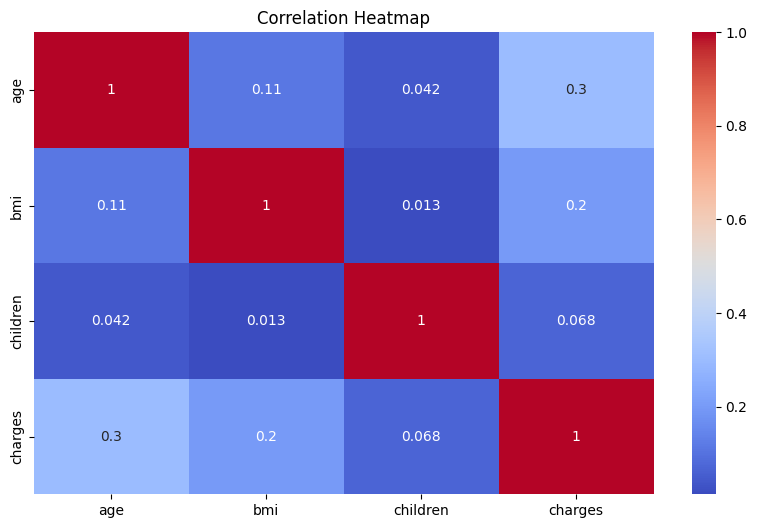

Text(0.5, 1.0, 'Distribution of Medical Charges')

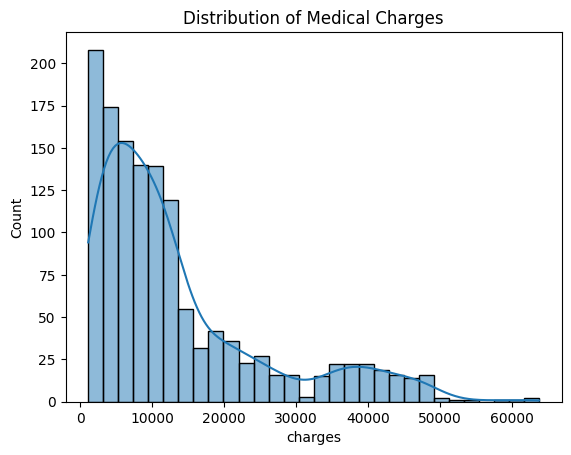

In [ ]:
# Check for missing values and duplicates
print(df.isnull().sum())
print(f"Duplicates found: {df.duplicated().sum()}")

# Visualizing correlations
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Distribution of Charges
sns.histplot(df['charges'], kde=True)
plt.title("Distribution of Medical Charges")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

5.

 When it comes to the encoding,since the independent variables are "sex", "region", "smokers", we needed to submit those variables into numerical elements. we need to provide numerical matrices to perform calculations(Pedregosa et al.,2011). for example "sex" would be described as "1" or "smokers would be descrbed as "2" etc.

Code Cell:

In [ ]:
# Convert categorical columns into numbers
df_encoded = pd.get_dummies(df,columns=['sex','smoker','region'],drop_first=True)
# Show first rows
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


6.


Note: Here we split the data (typically 80/20) and fit the Linear Regression model. We do this to make sure than no variable is above another (Geeks for Geeks,2024)

Code Cell:

In [ ]:
# Define Features (X) and Target (y)
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# Split into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

    #Train Linear Regression model
from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(X_train, y_train)

print("Model trained succcessfully")





Model trained succcessfully


7.

Code Cell:

In [ ]:
# Make predictions
y_pred = model.predict(X_test)

# Evaluate model
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 35478020.67523561
R2 Score: 0.8069287081198011


 (Interpretation):

if we analyse and look into the linear regression model, the model performed extremely well on the medical insurance data set. The R2 score of 0.8069287081198011 means that the model essentially explains 80.6% of the variation in medical terms. The 80.6% explains the variation in medical terms (Montgomery, Peck and Vining,2021). That means all the independent variables (sex, BMI etc) all have a strong relationship with the target variable.

8. References
- GeeksforGeeks(2024).Linear Regression in Python using Scikit-learn[Online].
Available at:
 https://www.geeksforgeeks.org/ml-linear-regression

(Accessed 15 April 2026)

- Mckinney, W.(2010). Data Structures for Statistical Computing in Python.Proceedings of the 9th Python in Science conference

- Montgomery, D. C., Peck, E. A. and Vinning, G. G. (2021). Introduction to Linear Regression Analysis. 6th edn. Hoboken: John Wiley and Sons.

- Pedregosa, F. et al. (2011). 'Scikit-learn: Machine Learning in Python', journal of Machine Learning Research, 12, pp.2825.-2830


